In [1]:
import sys
sys.path.insert(0, "..")

CONFIG = "../configs/supervised/resnet18_asymmetric.yaml"
SEED   = 42
DEVICE = "cuda"   # change to "cpu" if no GPU available

In [2]:
from scripts.run_pipeline_debug import run

results = run(config_path=CONFIG, seed=SEED, device=DEVICE)
print(f"\nReturned {len(results)} result dicts.")

2026-08-17 15:24:00,832:WARNING:reborn:__init__:<module>:

                     WARNING!!!
Failed to import the fortran-based modules in reborn.
Your code might still work since only a few parts of reborn
use fortran code, but you should set up your system so that 
numpy.f2py compiles fortran correctly. The most common issues are:
1) Your system does not have a fortran compiler. Solution: 
   Use a package manager to install gfortran or similar.  Any
   sensible AI prompt should be able to provide instructions.
2) Your system does not have the meson build system, which is 
   required for numpy versions greater than 1.26.  Solution:
   Use a package manager to install meson.  Any sensible AI 
   prompt should be able to provide instructions.
3) You upgraded numpy from version 1 to version 2, resulting in
   incompatible modules.  Solution: wipe out all of the existing
   compiled code with the command 
   $ python -m reborn --cleanup_fortran
4) You have an old numpy version (<1.26) and


══════════════════════════════════════════════════════════════
SFX PREPROCESSING DEBUG RUN — 8 frames  seed=42  device=cuda
══════════════════════════════════════════════════════════════
  [ 1] AGIPD          compressed0.cxi  frame 0
  [ 2] JUNGFRAU_4M    compressed7.cxi  frame 877
  [ 3] JUNGFRAU_4M    compressed7.cxi  frame 1307
  [ 4] JUNGFRAU_4M    compressed7.cxi  frame 866
  [ 5] ePix10k        compressed3.cxi  frame 805
  [ 6] ePix10k        compressed3.cxi  frame 376
  [ 7] Eiger4M        compressed4.cxi  frame 2942
  [ 8] Eiger4M        compressed4.cxi  frame 3044

━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
FRAME 1/8  AGIPD  compressed0.cxi  frame 0
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
  [Step  1] Read           1.089s  shape=(16, 512, 128)  dtype=float32  true_label=0
  [Step  2] Geometry       AGIPD 1M  (128 panels)
  [Step  3] Assembly       0.119s  shape=(1273, 1273)  min=0  max=4182
  [Step  4] Hitfinder      GPUHitfinder (gp

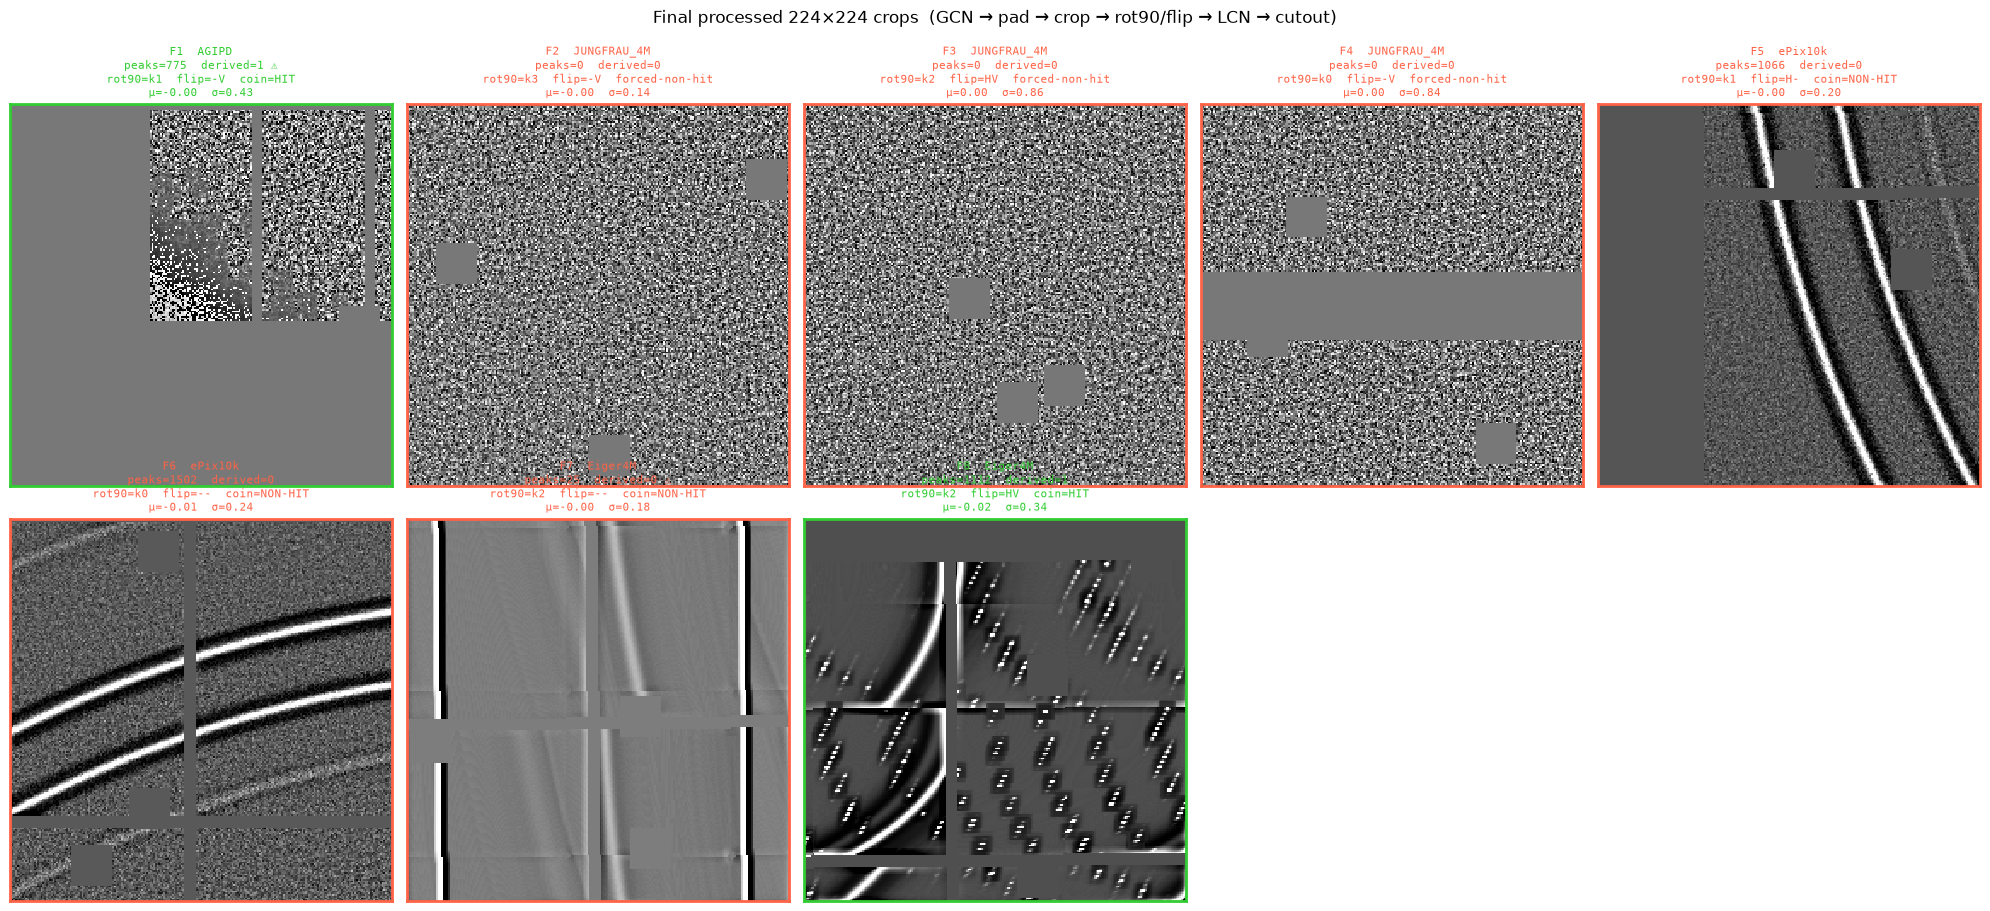

In [3]:
import matplotlib.pyplot as plt
import numpy as np

n = len(results)
ncols = 5
nrows = (n + ncols - 1) // ncols

fig, axes = plt.subplots(nrows, ncols, figsize=(ncols * 4, nrows * 4.5))
axes = np.array(axes).flatten()

for ax, r in zip(axes, results):
    img = r["tensor"].squeeze(0).numpy()          # (224, 224) float32
    vmin, vmax = np.percentile(img, [2, 98])
    ax.imshow(img, cmap="gray", vmin=vmin, vmax=vmax, origin="upper",
              interpolation="nearest")

    hit_color = "limegreen" if r["derived_label"] == 1 else "tomato"
    mismatch  = " ⚠" if r["label_mismatch"] else ""
    aug       = r["augment"]
    flip_str  = ("H" if aug["flip_h"] else "-") + ("V" if aug["flip_v"] else "-")
    crop_short = r["crop_decision"].split("  ")[0]

    title = (
        f"F{r['frame_no']}  {r['detector']}\n"
        f"peaks={r['n_peaks']}  derived={r['derived_label']}{mismatch}\n"
        f"rot90=k{aug['rot90_k']}  flip={flip_str}  {crop_short}\n"
        f"μ={img.mean():.2f}  σ={img.std():.2f}"
    )
    ax.set_title(title, fontsize=8, color=hit_color, family="monospace")

    for spine in ax.spines.values():
        spine.set_edgecolor(hit_color)
        spine.set_linewidth(2)
    ax.set_xticks([])
    ax.set_yticks([])

for ax in axes[n:]:
    ax.set_visible(False)

fig.suptitle(
    "Final processed 224×224 crops  (GCN → pad → crop → rot90/flip → LCN → cutout)",
    fontsize=12, y=1.01,
)
plt.tight_layout()
plt.show()


In [4]:
import pandas as pd

rows = []
for r in results:
    rows.append({
        "frame":         r["frame_no"],
        "detector":      r["detector"],
        "file":          r["file"],
        "frame_idx":     r["frame_idx"],
        "true_label":    r["true_label"],
        "n_peaks":       r["n_peaks"],
        "mismatch":      "⚠" if r["label_mismatch"] else "✓",
        "crop":          r["crop_decision"].split("  ")[0],
        "derived_label": r["derived_label"],
        "rot90_k":       r["augment"]["rot90_k"],
        "flip":          ("H" if r["augment"]["flip_h"] else "-") + ("V" if r["augment"]["flip_v"] else "-"),
        "gcn_max":       round(r["gcn_stats"]["max"], 2),
        "lcn_std":       round(r["lcn_stats"]["std"], 3),
        "assemble_ms":   round(r["assembly_time_s"] * 1000, 1),
    })

df = pd.DataFrame(rows).set_index("frame")
pd.set_option("display.max_colwidth", 30)
display(df)

,detector,file,frame_idx,true_label,n_peaks,mismatch,crop,derived_label,rot90_k,flip,gcn_max,lcn_std,assemble_ms
frame,,,,,,,,,,,,,
1,AGIPD,compressed0.cxi,0,0,775,⚠,coin=HIT,1,1,-V,3.53,0.436,119.2
2,JUNGFRAU_4M,compressed7.cxi,877,0,0,✓,forced-non-hit,0,3,-V,7.95,0.142,0.0
3,JUNGFRAU_4M,compressed7.cxi,1307,0,0,✓,forced-non-hit,0,2,HV,15.04,0.875,0.0
4,JUNGFRAU_4M,compressed7.cxi,866,0,0,✓,forced-non-hit,0,0,-V,4.70,0.857,0.0
5,ePix10k,compressed3.cxi,805,1,1066,✓,coin=NON-HIT,0,1,H-,9.34,0.197,252.2
6,ePix10k,compressed3.cxi,376,1,1502,✓,coin=NON-HIT,0,0,--,8.29,0.238,264.1
7,Eiger4M,compressed4.cxi,2942,0,25,⚠,coin=NON-HIT,0,2,--,5.81,0.180,241.6
8,Eiger4M,compressed4.cxi,3044,1,1112,✓,coin=HIT,1,2,HV,47.07,0.346,265.8
